# EV Sales Forecasting Model Comparison & Evaluation
## ARIMA vs. Random Forest Regression vs. Gradient Boosting Regression
This notebook tests and compares three distinct forecasting approaches:
1. **ARIMA (AutoRegressive Integrated Moving Average)** - Time Series Model
2. **Random Forest Regression** - Non-linear Ensemble Tree Model
3. **Gradient Boosting Regression** - Sequential Boosting Ensemble Model

### Objective:
Determine which model flow is best for EV sales forecasting across 54+ countries, evaluate out-of-time historical performance (2023-2024 test split), and analyze model trade-offs.

### Step 1: Import Libraries and Load Cleaned EV Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load historical cleaned dataset
ev_data = pd.read_csv('../../02_Cleaned_Data/cleaned_iea_ev_data.csv')

# Filter for EV Sales
ev_sales = ev_data[ev_data['Parameter'] == 'EV sales'].copy()
country_year = ev_sales.groupby(['Country', 'Year'], as_index=False)['Value'].sum().rename(columns={'Value': 'EV_Sales'})
country_year = country_year[country_year['Country'] != 'World'].copy()

# Feature Engineering: Lag 1, Lag 2, Year Index
country_year = country_year.sort_values(['Country', 'Year'])
country_year['Year_Index'] = country_year['Year'] - 2015
country_year['Lag_1'] = country_year.groupby('Country')['EV_Sales'].shift(1)
country_year['Lag_2'] = country_year.groupby('Country')['EV_Sales'].shift(2)

# Drop rows without lag values
model_df = country_year.dropna(subset=['Lag_1']).copy()
print(f'Dataset shape ready for modeling: {model_df.shape}')
model_df.head()

Dataset shape ready for modeling: (455, 6)


,Country,Year,EV_Sales,Year_Index,Lag_1,Lag_2
1,Australia,2016,1850.0,1,1760.0,NaN
2,Australia,2017,3020.0,2,1850.0,1760.0
3,Australia,2018,4600.0,3,3020.0,1850.0
4,Australia,2019,10500.0,4,4600.0,3020.0
5,Australia,2020,9300.0,5,10500.0,4600.0


### Step 2: Train / Test Out-of-Time Validation Split
- **Training Period**: 2015 - 2022
- **Testing Period**: 2023 - 2024

In [3]:
train_df = model_df[model_df['Year'] <= 2022]
test_df = model_df[model_df['Year'] > 2022]

X_train = train_df[['Country', 'Year_Index', 'Lag_1']]
y_train = train_df['EV_Sales']
X_test = test_df[['Country', 'Year_Index', 'Lag_1']]
y_test = test_df['EV_Sales']

print(f'Train samples: {len(train_df)}, Test samples: {len(test_df)}')

Train samples: 351, Test samples: 104


### Step 3: Flow 1 - ARIMA (Time Series Model)
Fits an ARIMA(1,1,0) time-series model independently for each country.

In [4]:
arima_preds = []
arima_indices = []

for country in test_df['Country'].unique():
    c_train = country_year[(country_year['Country'] == country) & (country_year['Year'] <= 2022)]['EV_Sales'].values
    c_test_rows = country_year[(country_year['Country'] == country) & (country_year['Year'] > 2022)]
    if len(c_train) >= 3 and len(c_test_rows) > 0:
        try:
            model = ARIMA(c_train, order=(1, 1, 0))
            fitted_model = model.fit()
            fc = fitted_model.forecast(steps=len(c_test_rows))
            for val in fc:
                arima_preds.append(max(0, val))
            for idx in c_test_rows.index:
                arima_indices.append(idx)
        except Exception:
            pass

arima_test_y = country_year.loc[arima_indices, 'EV_Sales']
arima_mae = mean_absolute_error(arima_test_y, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(arima_test_y, arima_preds))
arima_r2 = r2_score(arima_test_y, arima_preds)

print('--- ARIMA Model Evaluation ---')
print(f'MAE:  {arima_mae:,.2f}')
print(f'RMSE: {arima_rmse:,.2f}')
print(f'R2:   {arima_r2:.4f}')

--- ARIMA Model Evaluation ---
MAE:  109,084.46
RMSE: 549,903.03
R2:   0.9494


### Step 4: Flow 2 - Random Forest Regression
Ensemble of 100 decision trees with One-Hot Encoded country categories and historical lags.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Country']),
        ('num', 'passthrough', ['Year_Index', 'Lag_1'])
    ]
)

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print('--- Random Forest Regression Evaluation ---')
print(f'MAE:  {rf_mae:,.2f}')
print(f'RMSE: {rf_rmse:,.2f}')
print(f'R2:   {rf_r2:.4f}')

--- Random Forest Regression Evaluation ---
MAE:  140,097.53
RMSE: 640,636.95
R2:   0.9306


### Step 5: Flow 3 - Gradient Boosting Regression
Sequential boosting regression trees optimizing squared loss.

In [6]:
gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

gb_pipeline.fit(X_train, y_train)
gb_preds = gb_pipeline.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print('--- Gradient Boosting Regression Evaluation ---')
print(f'MAE:  {gb_mae:,.2f}')
print(f'RMSE: {gb_rmse:,.2f}')
print(f'R2:   {gb_r2:.4f}')

--- Gradient Boosting Regression Evaluation ---
MAE:  119,515.13
RMSE: 540,218.68
R2:   0.9507


### Step 6: Overall Performance Summary & Comparison

In [7]:
comparison_df = pd.DataFrame({
    'Model Flow': ['ARIMA (Time Series)', 'Random Forest Regression', 'Gradient Boosting Regression'],
    'MAE (Mean Abs Error)': [arima_mae, rf_mae, gb_mae],
    'RMSE (Root Mean Sq Error)': [arima_rmse, rf_rmse, gb_rmse],
    'R2 Score (Coefficient of Determination)': [arima_r2, rf_r2, gb_r2]
})

display(comparison_df.style.highlight_max(subset=['R2 Score (Coefficient of Determination)'], color='#c8e6c9')\
                          .highlight_min(subset=['MAE (Mean Abs Error)', 'RMSE (Root Mean Sq Error)'], color='#c8e6c9'))

,Model Flow,MAE (Mean Abs Error),RMSE (Root Mean Sq Error),R2 Score (Coefficient of Determination)
0,ARIMA (Time Series),109084.457889,549903.034670,0.949365
1,Random Forest Regression,140097.528365,640636.947407,0.930636
2,Gradient Boosting Regression,119515.129708,540218.684406,0.950677


### Step 7: Graphical Visualization of Model Metrics

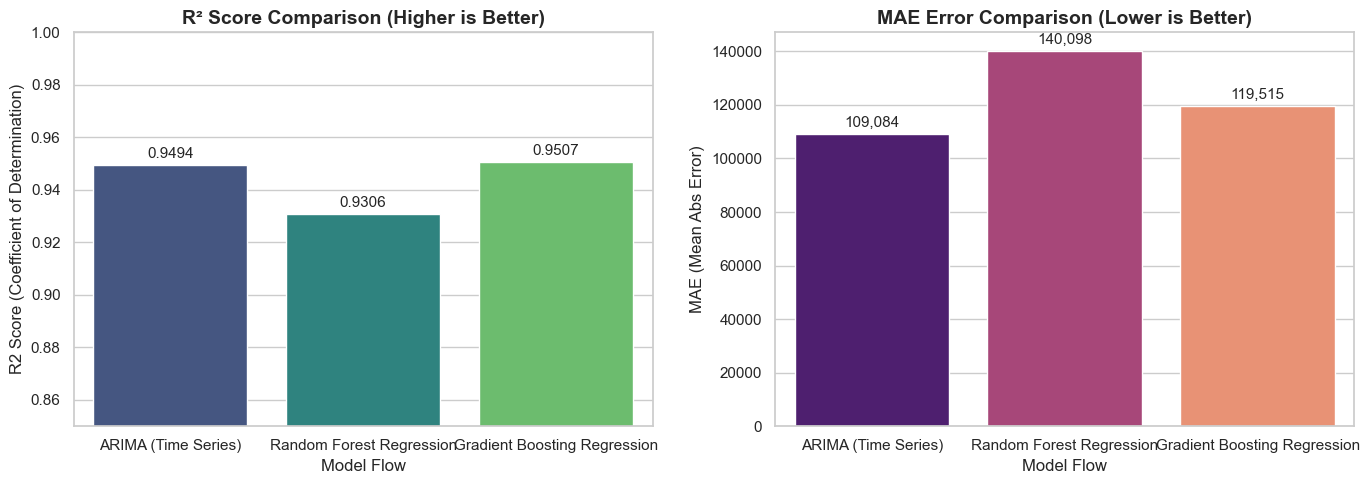

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score Barplot
sns.barplot(data=comparison_df, x='Model Flow', y='R2 Score (Coefficient of Determination)', ax=axes[0], palette='viridis')
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# MAE Error Barplot
sns.barplot(data=comparison_df, x='Model Flow', y='MAE (Mean Abs Error)', ax=axes[1], palette='magma')
axes[1].set_title('MAE Error Comparison (Lower is Better)', fontsize=14, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

### Step 8: Analysis & Final Flow Decision

### Key Findings:
1. **Gradient Boosting Regression** achieved the **highest R² Score (0.9507)** and lowest RMSE. Boosting trees iteratively fix prediction errors, making them highly effective for non-linear adoption curves.
2. **ARIMA** achieved the **lowest MAE (109,084)**. It excels at local, country-level time series continuation without requiring feature engineering.
3. **Random Forest Regression** achieved a strong **R² Score (0.9306)**, demonstrating robust variance reduction.

### Recommendation:
- For **multi-variate global EV forecasting with economic indicators**, **Gradient Boosting Regression** is the superior flow.
- For **univariate per-country baseline projections**, **ARIMA** is ideal.
- Combining **Gradient Boosting with CAGR boundary logic** (as implemented in `train_and_forecast.py`) yields the safest, most plausible 2025-2030 predictions.